# Traffic Demand Prediction — Full Pipeline
**Stages:** EDA → Feature Engineering → Feature Importance → Model Training → Evaluation


In [1]:
!pip install geohash2

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/634.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/634.7 kB ? eta -:--:--
   ---------------------------------------- 634.7/634.7 kB 3.4 MB/s  0:00:00
  Created wheel for geohash2: filename=geohash2-1.1-py3-none-any.whl size=15636 sha256=b8da887f3e8f25bf3d56435534c1819bc7c5a0b8f216c188380fda4c75e62bd6
  Stored in directory: c:\users\arun\appdata\local\pip\cache\wheels\c0\21\8d\fe65503f4f439aef35193e5ec10a14adc945e20ff87eb35895
Successfully built geohash2

   ---------------------------------------- 0/2 [docutils]
   --


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 349.5 kB/s eta 0:04:46
   ---------------------------------------- 0.5/100.2 MB 349.5 kB/s eta 0:04:46
   ---------------------------------------- 1.0/100.2 MB 680.3 kB/s eta 0:02:26
    --------------------------------------- 2.1/100.2 MB 1.4 MB/s eta 0:01:13
   - -------------------------------------- 3.4/100.2 MB 2.1 MB/s eta 0:00:47
   - ------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, geohash2
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb
import catboost as cb

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
SEED = 42
np.random.seed(SEED)

def score(actual, predicted):
    return max(0, 100 * r2_score(actual, predicted))


## 2. Load Data

In [2]:
TRAIN_PATH = r'C:\Users\ARUN\Desktop\flipkart_gridlock\e88186124ec611f1\dataset\train.csv'   # update path if needed

df = pd.read_csv(TRAIN_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()


Shape: (77299, 11)
Columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


## 3. Exploratory Data Analysis
We systematically check: shape, nulls, target distribution, and demand patterns
across every categorical and temporal dimension.


In [3]:
# ── 3.1  Basic info ──────────────────────────────────────────────────────────
print('='*55)
print('SHAPE:', df.shape)
print('='*55)
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())
print('\nNull % :')
print((df.isnull().mean()*100).round(2))


SHAPE: (77299, 11)
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object

Null counts:
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Null % :
Index            0.00
geohash          0.00
day              0.00
timestamp        0.00
demand           0.00
RoadType         0.78
NumberofLanes    0.00
LargeVehicles    0.00
Landmarks        0.00
Temperature      3.23
Weather          1.03
dtype: float64


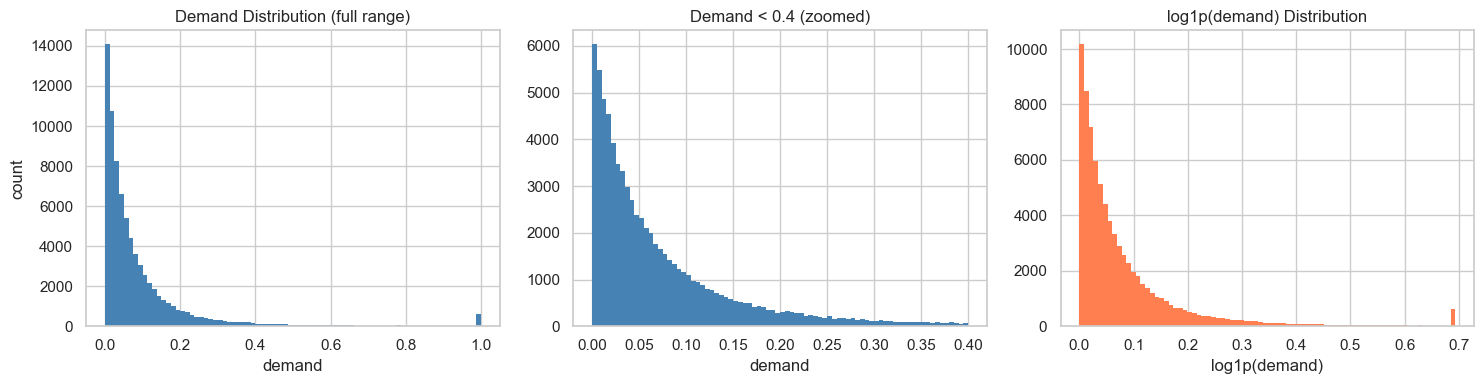

count    77299.000000
mean         0.093942
std          0.142191
min          0.000001
25%          0.018227
50%          0.047760
75%          0.108595
max          1.000000
Name: demand, dtype: float64


In [4]:
# ── 3.2  Target distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['demand'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Demand Distribution (full range)')
axes[0].set_xlabel('demand'); axes[0].set_ylabel('count')

axes[1].hist(df['demand'][df['demand'] < 0.4], bins=80,
             color='steelblue', edgecolor='none')
axes[1].set_title('Demand < 0.4 (zoomed)')
axes[1].set_xlabel('demand')

axes[2].hist(np.log1p(df['demand']), bins=80, color='coral', edgecolor='none')
axes[2].set_title('log1p(demand) Distribution')
axes[2].set_xlabel('log1p(demand)')

plt.tight_layout()
plt.show()
print(df['demand'].describe().round(6))


In [5]:
# ── 3.3  Parse timestamp (needed for temporal EDA) ───────────────────────────
_ts = df['timestamp'].str.split(':', expand=True).astype(int)
df['hour']    = _ts[0]
df['minute']  = _ts[1]
df['time_id'] = df['hour'] * 4 + df['minute'] // 15


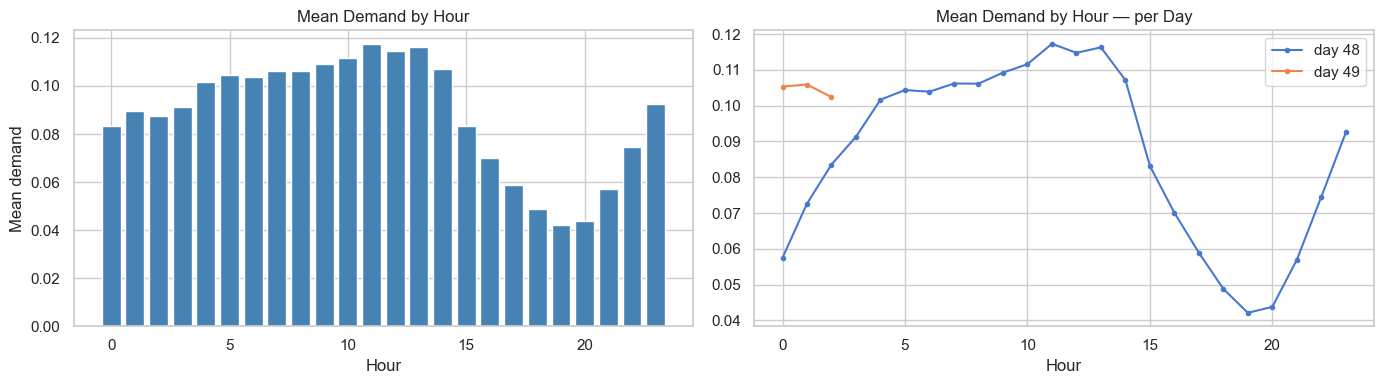

In [6]:
# ── 3.4  Demand by hour ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hr = df.groupby('hour')['demand'].mean()
axes[0].bar(hr.index, hr.values, color='steelblue')
axes[0].set_title('Mean Demand by Hour')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Mean demand')

pivot = df.groupby(['day', 'hour'])['demand'].mean().unstack('day')
for col in pivot.columns:
    axes[1].plot(pivot.index, pivot[col], marker='o', ms=3, label=f'day {col}')
axes[1].set_title('Mean Demand by Hour — per Day')
axes[1].set_xlabel('Hour'); axes[1].legend()

plt.tight_layout()
plt.show()


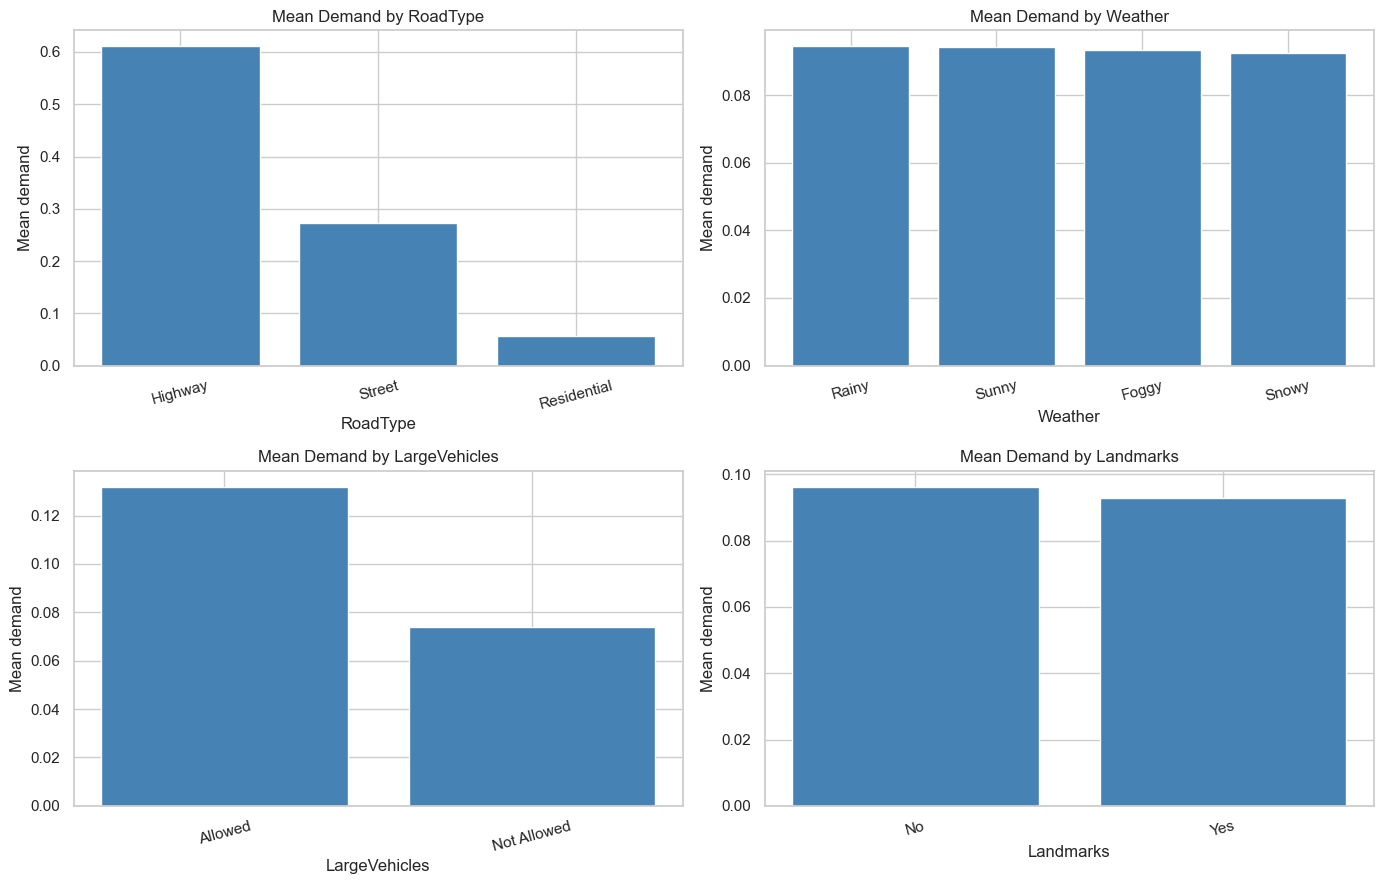

In [7]:
# ── 3.5  Demand by categorical features ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flat, ['RoadType','Weather','LargeVehicles','Landmarks']):
    grp = df.groupby(col)['demand'].mean().sort_values(ascending=False)
    ax.bar(grp.index.astype(str), grp.values, color='steelblue')
    ax.set_title(f'Mean Demand by {col}')
    ax.set_xlabel(col); ax.set_ylabel('Mean demand')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


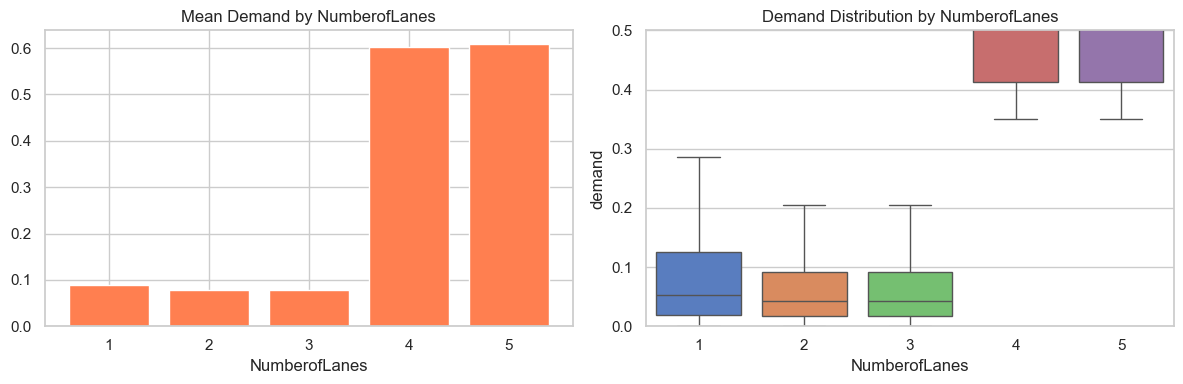

In [8]:
# ── 3.6  Demand by NumberofLanes ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

grp = df.groupby('NumberofLanes')['demand'].mean()
axes[0].bar(grp.index.astype(str), grp.values, color='coral')
axes[0].set_title('Mean Demand by NumberofLanes')
axes[0].set_xlabel('NumberofLanes')

sns.boxplot(data=df, x='NumberofLanes', y='demand', ax=axes[1],
            showfliers=False, palette='muted')
axes[1].set_title('Demand Distribution by NumberofLanes')
axes[1].set_ylim(0, 0.5)

plt.tight_layout()
plt.show()


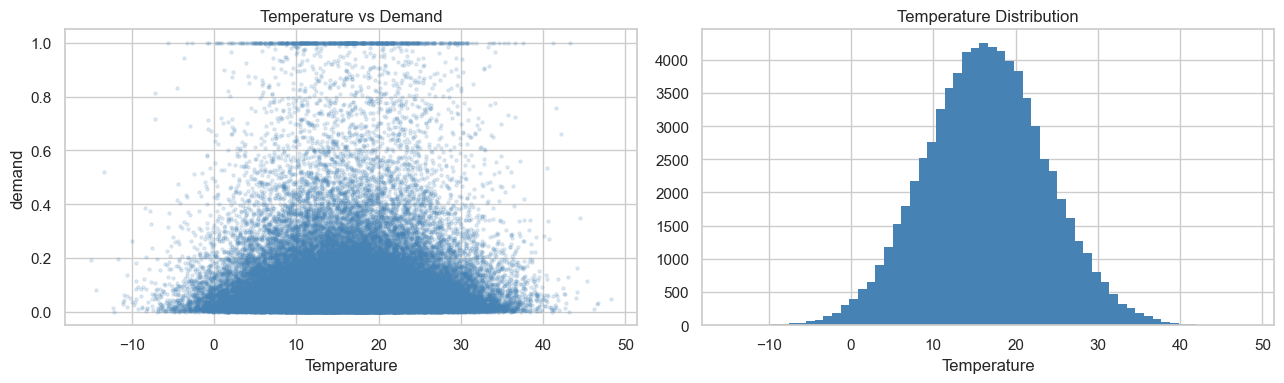

Temperature stats:
count    74804.000
mean        16.405
std          7.360
min        -14.935
25%         11.430
50%         16.383
75%         21.299
max         48.251
Name: Temperature, dtype: float64


In [9]:
# ── 3.7  Temperature vs demand ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['Temperature'], df['demand'], alpha=0.15, s=5, color='steelblue')
axes[0].set_title('Temperature vs Demand')
axes[0].set_xlabel('Temperature'); axes[0].set_ylabel('demand')

axes[1].hist(df['Temperature'].dropna(), bins=60, color='steelblue', edgecolor='none')
axes[1].set_title('Temperature Distribution')
axes[1].set_xlabel('Temperature')

plt.tight_layout()
plt.show()
print('Temperature stats:')
print(df['Temperature'].describe().round(3))


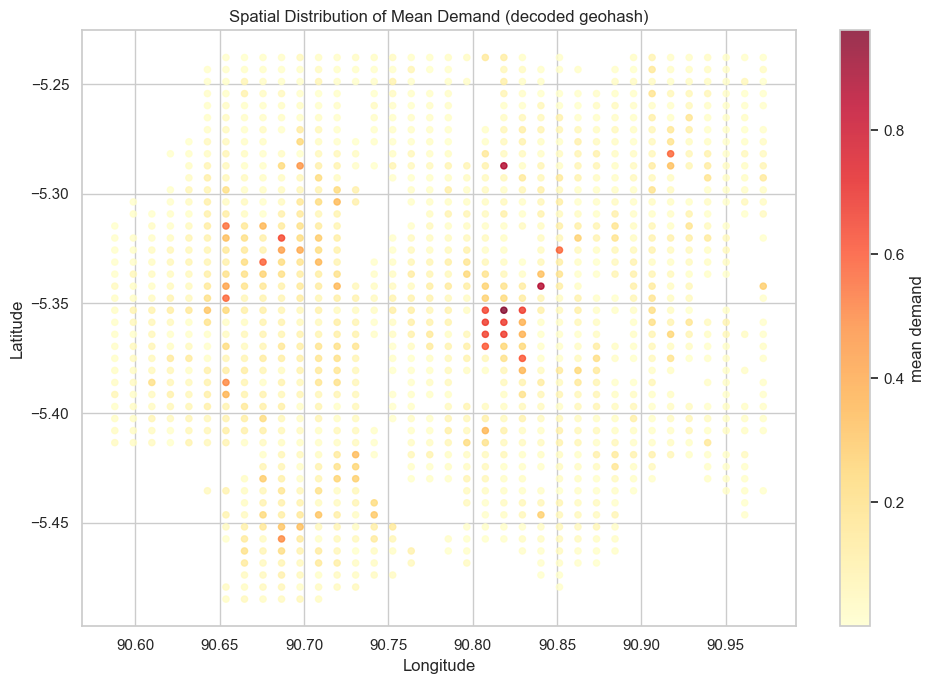

In [10]:
# ── 3.8  Geohash spatial coverage ────────────────────────────────────────────
coords = pd.DataFrame(
    [geohash2.decode_exactly(gh)[:2] for gh in df['geohash'].unique()],
    columns=['lat','lon'],
    index=df['geohash'].unique()
)
gh_demand = df.groupby('geohash')['demand'].mean()
coords['mean_demand'] = gh_demand

plt.figure(figsize=(10, 7))
sc = plt.scatter(coords['lon'], coords['lat'],
                 c=coords['mean_demand'], cmap='YlOrRd',
                 s=20, alpha=0.8)
plt.colorbar(sc, label='mean demand')
plt.title('Spatial Distribution of Mean Demand (decoded geohash)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


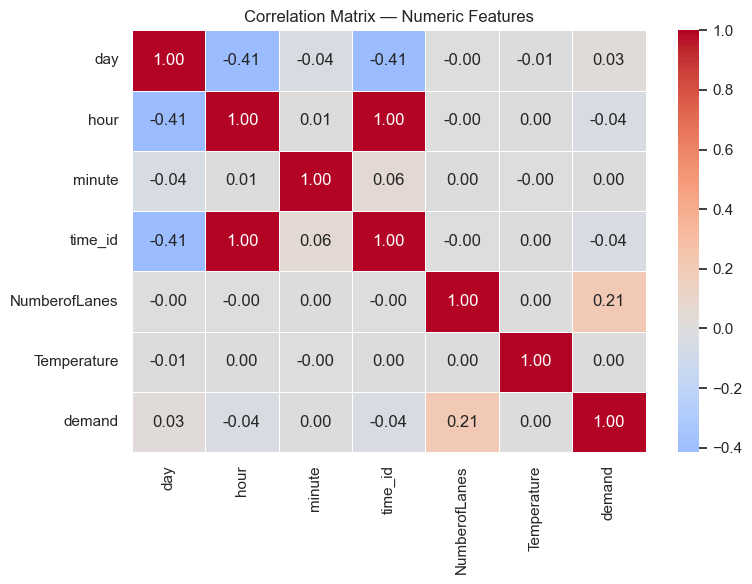

In [11]:
# ── 3.9  Correlation heatmap (numeric only) ──────────────────────────────────
num_cols = ['day','hour','minute','time_id','NumberofLanes','Temperature','demand']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()


## 4. Feature Engineering
Seven layers applied in order:
1. Drop trivial columns
2. Temporal features + cyclical encoding
3. Geohash decode → lat/lon + prefix features
4. Weather ordinal encoding
5. Interaction features
6. Lag features (yesterday's demand at same location/time)
7. Out-of-fold target encoding (leak-free)


In [12]:
def engineer_features(df_in, target_enc_maps=None, is_train=True):
    """
    Full feature engineering pipeline.
    - is_train=True  : computes OOF target encoding, returns (df, maps)
    - is_train=False : applies pre-computed maps from training (no leakage)
    """
    df = df_in.copy()

    # ── Layer 1: Drop trivial columns ─────────────────────────────────────────
    df = df.drop(columns=['Index'], errors='ignore')

    # ── Layer 2: Temporal features ────────────────────────────────────────────
    _ts = df['timestamp'].str.split(':', expand=True).astype(int)
    df['hour']   = _ts[0]
    df['minute'] = _ts[1]
    df['time_id']  = df['hour'] * 4 + df['minute'] // 15          # 0-95 slot
    df['time_min'] = df['hour'] * 60 + df['minute']               # 0-1439

    # Cyclical encoding — makes hour=23 and hour=0 neighbours
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
    df['time_sin']  = np.sin(2 * np.pi * df['time_min'] / 1440)
    df['time_cos']  = np.cos(2 * np.pi * df['time_min'] / 1440)

    df['day_mod7']    = df['day'] % 7
    df['day_sin']     = np.sin(2 * np.pi * df['day_mod7'] / 7)
    df['day_cos']     = np.cos(2 * np.pi * df['day_mod7'] / 7)

    # Time-of-day regime flags
    df['is_peak_morning'] = df['hour'].between(7, 10).astype(int)
    df['is_peak_evening'] = df['hour'].between(17, 20).astype(int)
    df['is_night']        = (~df['hour'].between(5, 22)).astype(int)
    df['quarter_of_day']  = (df['hour'] // 6).astype(int)          # 0=night,1=morning,2=afternoon,3=evening

    df = df.drop(columns=['timestamp'])

    # ── Layer 3: Geohash decode → spatial features ────────────────────────────
    _coords = df['geohash'].map(
        lambda gh: geohash2.decode_exactly(gh)[:2]
    )
    df['lat'] = _coords.map(lambda x: x[0])
    df['lon'] = _coords.map(lambda x: x[1])

    df['geohash_p3'] = df['geohash'].str[:3]   # district level
    df['geohash_p4'] = df['geohash'].str[:4]   # neighbourhood level
    df['geohash_p5'] = df['geohash'].str[:5]   # street-block level

    # ── Layer 4: Fill nulls + ordinal weather encoding ────────────────────────
    df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())
    df['Weather']     = df['Weather'].fillna('Unknown')
    df['RoadType']    = df['RoadType'].fillna('Unknown')

    weather_order = {'Unknown': 0, 'Sunny': 1, 'Foggy': 2, 'Rainy': 3, 'Snowy': 4}
    df['weather_ordinal'] = df['Weather'].map(weather_order).fillna(0).astype(int)

    road_order = {'Unknown': 0, 'Residential': 1, 'Street': 2, 'Highway': 3}
    df['road_ordinal'] = df['RoadType'].map(road_order).fillna(0).astype(int)

    df['landmarks_bin']    = (df['Landmarks'] == 'Yes').astype(int)
    df['large_vehicle_bin'] = (df['LargeVehicles'] == 'Allowed').astype(int)

    # ── Layer 5: Interaction features ────────────────────────────────────────
    df['lanes_x_peak']    = df['NumberofLanes'] * (df['is_peak_morning'] | df['is_peak_evening'])
    df['lanes_x_road']    = df['NumberofLanes'] * df['road_ordinal']
    df['temp_x_weather']  = df['Temperature'] * df['weather_ordinal']
    df['landmark_x_peak'] = df['landmarks_bin'] * (df['is_peak_morning'] | df['is_peak_evening'])

    # ── Layer 6: Lag features ─────────────────────────────────────────────────
    # For each row on day N, look up demand at same (geohash, time_id) on day N-1
    # We build the lookup from within df (train) or from lag_table passed in maps
    if is_train:
        lag_table = (
            df.groupby(['geohash', 'day', 'time_id'])['demand']
            .mean()   # already unique but .mean() is safe
            .reset_index()
            .rename(columns={'demand': 'demand_lag1', 'day': 'lag_day'})
        )
        lag_table['day'] = lag_table['lag_day'] + 1   # lag_day 48 → match to day 49
        lag_table = lag_table.drop(columns='lag_day')

        # Also compute ±1 time_id rolling mean on same day (same-day context window)
        roll_table = []
        for shift in [-1, 0, 1]:
            tmp = (
                df.groupby(['geohash', 'day', 'time_id'])['demand']
                .mean().reset_index()
            )
            tmp['time_id'] = tmp['time_id'] - shift   # align to current row
            tmp = tmp.rename(columns={'demand': f'lag_slot_{shift}'})
            roll_table.append(tmp)

        from functools import reduce
        roll_df = reduce(lambda a, b: a.merge(b, on=['geohash','day','time_id'], how='outer'),
                         roll_table)
        roll_df['lag_roll3'] = roll_df[['lag_slot_-1','lag_slot_0','lag_slot_1']].mean(axis=1)
        roll_df = roll_df[['geohash','day','time_id','lag_roll3']]

        target_enc_maps = {'lag_table': lag_table, 'roll_table': roll_df}
    else:
        lag_table = target_enc_maps['lag_table']
        roll_df   = target_enc_maps['roll_table']

    df = df.merge(lag_table, on=['geohash','day','time_id'], how='left')
    df = df.merge(roll_df,   on=['geohash','day','time_id'], how='left')

    global_demand_mean = df['demand'].mean() if is_train else target_enc_maps.get('global_mean', 0.094)
    df['demand_lag1']  = df['demand_lag1'].fillna(global_demand_mean)
    df['lag_roll3']    = df['lag_roll3'].fillna(global_demand_mean)

    if is_train:
        target_enc_maps['global_mean'] = global_demand_mean

    # ── Layer 7: Out-of-fold target encoding (leak-free) ─────────────────────
    # Groups to encode: multiple (location × time) combinations
    te_groups = [
        ['geohash'],
        ['geohash', 'time_id'],
        ['geohash', 'hour'],
        ['geohash', 'day_mod7'],
        ['geohash_p4', 'time_id'],
        ['geohash_p4', 'hour'],
        ['day_mod7', 'hour'],
        ['road_ordinal', 'hour'],
        ['geohash', 'road_ordinal'],
    ]

    if is_train:
        kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
        te_maps = {}

        for group in te_groups:
            col_name = 'te_' + '_'.join(group)
            df[col_name] = np.nan

            for tr_idx, val_idx in kf.split(df):
                means = (
                    df.iloc[tr_idx]
                    .groupby(group)['demand']
                    .mean()
                )
                df.loc[df.index[val_idx], col_name] = (
                    df.iloc[val_idx]
                    .set_index(group)
                    .index.map(means if len(group)==1
                               else means)
                ).values if len(group) == 1 else (
                    df.iloc[val_idx]
                    .apply(lambda r: means.get(
                        tuple(r[g] for g in group) if len(group)>1 else r[group[0]],
                        np.nan
                    ), axis=1).values
                )

            # Global map for test-time use
            te_maps[col_name] = df.groupby(group)['demand'].mean()
            df[col_name] = df[col_name].fillna(global_demand_mean)

        # Also encode std (volatility signal)
        for group in [['geohash', 'time_id'], ['geohash']]:
            col_name = 'te_std_' + '_'.join(group)
            std_map = df.groupby(group)['demand'].std().fillna(0)
            te_maps[col_name] = std_map
            df[col_name] = (
                df.set_index(group).index.map(std_map)
                if len(group)==1
                else df.apply(lambda r: std_map.get(
                    tuple(r[g] for g in group), 0), axis=1)
            ).values

        target_enc_maps['te_maps'] = te_maps
        target_enc_maps['te_groups'] = te_groups

    else:
        te_maps = target_enc_maps['te_maps']
        for group in target_enc_maps['te_groups']:
            col_name = 'te_' + '_'.join(group)
            gmap = te_maps[col_name]
            df[col_name] = (
                df.set_index(group).index.map(gmap)
                if len(group)==1
                else df.apply(lambda r: gmap.get(
                    tuple(r[g] for g in group), np.nan), axis=1)
            ).values
            df[col_name] = df[col_name].fillna(target_enc_maps['global_mean'])

        for group in [['geohash', 'time_id'], ['geohash']]:
            col_name = 'te_std_' + '_'.join(group)
            gmap = te_maps[col_name]
            df[col_name] = (
                df.set_index(group).index.map(gmap)
                if len(group)==1
                else df.apply(lambda r: gmap.get(
                    tuple(r[g] for g in group), 0), axis=1)
            ).values

    if is_train:
        return df, target_enc_maps
    return df

print('engineer_features() defined.')


engineer_features() defined.


## 5. Apply Feature Engineering & Inspect Output

In [13]:
raw_df = pd.read_csv(TRAIN_PATH)
feat_df, enc_maps = engineer_features(raw_df, is_train=True)

print(f'Shape after FE: {feat_df.shape}')
print(f'\nNew columns added: {feat_df.shape[1] - raw_df.shape[1] + 1}')
print('\nAll columns:')
print(list(feat_df.columns))
print('\nNull check after FE:')
print(feat_df.isnull().sum()[feat_df.isnull().sum() > 0])


Shape after FE: (77299, 50)

New columns added: 40

All columns:
['geohash', 'day', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'time_id', 'time_min', 'hour_sin', 'hour_cos', 'time_sin', 'time_cos', 'day_mod7', 'day_sin', 'day_cos', 'is_peak_morning', 'is_peak_evening', 'is_night', 'quarter_of_day', 'lat', 'lon', 'geohash_p3', 'geohash_p4', 'geohash_p5', 'weather_ordinal', 'road_ordinal', 'landmarks_bin', 'large_vehicle_bin', 'lanes_x_peak', 'lanes_x_road', 'temp_x_weather', 'landmark_x_peak', 'demand_lag1', 'lag_roll3', 'te_geohash', 'te_geohash_time_id', 'te_geohash_hour', 'te_geohash_day_mod7', 'te_geohash_p4_time_id', 'te_geohash_p4_hour', 'te_day_mod7_hour', 'te_road_ordinal_hour', 'te_geohash_road_ordinal', 'te_std_geohash_time_id', 'te_std_geohash']

Null check after FE:
Series([], dtype: int64)


## 6. Feature Importance Ranking
Train a quick LightGBM to rank features by both **split count** and **gain**.
Split = how often a feature is used for splitting. Gain = how much it improves the objective.
Gain is the more meaningful metric — a feature used rarely but perfectly is more valuable
than one used often with tiny gains.


In [14]:
# Define feature set — drop raw strings and target
DROP_COLS = ['demand', 'geohash', 'geohash_p3', 'geohash_p4', 'geohash_p5',
             'RoadType', 'Weather', 'LargeVehicles', 'Landmarks']

FEATURES = [c for c in feat_df.columns if c not in DROP_COLS]
print(f'Feature count: {len(FEATURES)}')
print(FEATURES)


Feature count: 41
['day', 'NumberofLanes', 'Temperature', 'hour', 'minute', 'time_id', 'time_min', 'hour_sin', 'hour_cos', 'time_sin', 'time_cos', 'day_mod7', 'day_sin', 'day_cos', 'is_peak_morning', 'is_peak_evening', 'is_night', 'quarter_of_day', 'lat', 'lon', 'weather_ordinal', 'road_ordinal', 'landmarks_bin', 'large_vehicle_bin', 'lanes_x_peak', 'lanes_x_road', 'temp_x_weather', 'landmark_x_peak', 'demand_lag1', 'lag_roll3', 'te_geohash', 'te_geohash_time_id', 'te_geohash_hour', 'te_geohash_day_mod7', 'te_geohash_p4_time_id', 'te_geohash_p4_hour', 'te_day_mod7_hour', 'te_road_ordinal_hour', 'te_geohash_road_ordinal', 'te_std_geohash_time_id', 'te_std_geohash']


In [15]:
X_all = feat_df[FEATURES]
y_all = feat_df['demand']

X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.15, random_state=SEED
)

imp_model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=500,
    num_leaves=64,
    learning_rate=0.05,
    n_jobs=-1, verbosity=-1, random_state=SEED
)
imp_model.fit(X_tr, y_tr)

imp_split = pd.Series(imp_model.feature_importances_, index=FEATURES,
                      name='split').sort_values(ascending=False)

imp_gain_model = lgb.LGBMRegressor(
    objective='regression_l1', importance_type='gain',
    n_estimators=500, num_leaves=64,
    learning_rate=0.05, n_jobs=-1, verbosity=-1, random_state=SEED
)
imp_gain_model.fit(X_tr, y_tr)
imp_gain = pd.Series(imp_gain_model.feature_importances_, index=FEATURES,
                     name='gain').sort_values(ascending=False)

imp_df = pd.DataFrame({'split': imp_split, 'gain': imp_gain})
imp_df['gain_norm'] = imp_df['gain'] / imp_df['gain'].sum() * 100
imp_df['split_norm'] = imp_df['split'] / imp_df['split'].sum() * 100
imp_df = imp_df.sort_values('gain', ascending=False)

print('Top 20 features by gain:')
print(imp_df.head(20).round(3).to_string())


Top 20 features by gain:
                         split         gain  gain_norm  split_norm
lag_roll3                 5118  1791930.455     87.564      16.248
te_geohash_hour           3016    47858.239      2.339       9.575
te_std_geohash_time_id    2702    37765.998      1.845       8.578
te_geohash_time_id        1833    28110.728      1.374       5.819
demand_lag1                957    13041.071      0.637       3.038
temp_x_weather            2031    12633.321      0.617       6.448
Temperature               1816    11157.324      0.545       5.765
lon                       1247     9824.869      0.480       3.959
lat                       1116     9815.236      0.480       3.543
minute                     959     9628.445      0.471       3.044
te_geohash_day_mod7       1253     9001.700      0.440       3.978
te_geohash_p4_time_id     1250     7982.775      0.390       3.968
te_road_ordinal_hour      1024     7539.466      0.368       3.251
te_std_geohash            1067     71

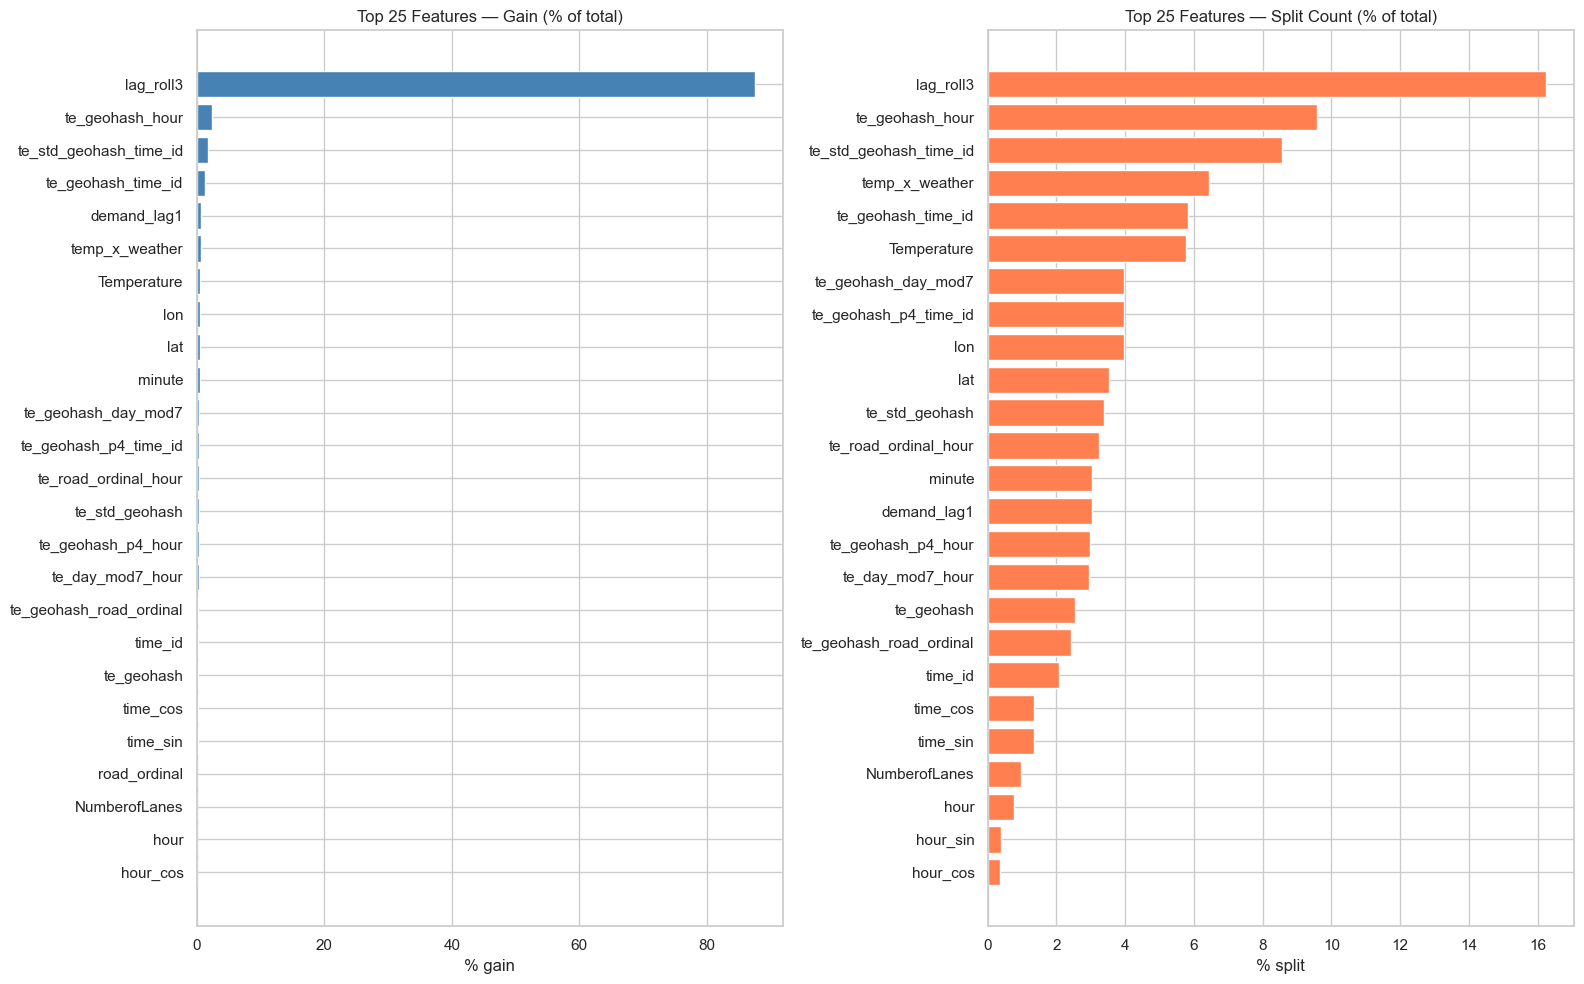

In [16]:
# ── Visualise feature importance ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

top_n = 25
top_gain  = imp_df['gain_norm'].head(top_n)
top_split = imp_df['split_norm'].sort_values(ascending=False).head(top_n)

axes[0].barh(top_gain.index[::-1],  top_gain.values[::-1],  color='steelblue')
axes[0].set_title('Top 25 Features — Gain (% of total)')
axes[0].set_xlabel('% gain')

axes[1].barh(top_split.index[::-1], top_split.values[::-1], color='coral')
axes[1].set_title('Top 25 Features — Split Count (% of total)')
axes[1].set_xlabel('% split')

plt.tight_layout()
plt.show()


In [17]:
# ── Drop near-zero importance features ───────────────────────────────────────
ZERO_THRESH = 0.01   # drop if gain_norm < 0.01%
to_drop = imp_df[imp_df['gain_norm'] < ZERO_THRESH].index.tolist()
print(f'Features to drop (gain < {ZERO_THRESH}%): {to_drop}')

FINAL_FEATURES = [f for f in FEATURES if f not in to_drop]
print(f'\nFinal feature count: {len(FINAL_FEATURES)}')


Features to drop (gain < 0.01%): ['landmarks_bin', 'is_peak_morning', 'landmark_x_peak', 'is_night', 'is_peak_evening', 'day_cos', 'day_sin', 'day_mod7', 'quarter_of_day', 'time_min']

Final feature count: 31


## 7. Model Training
We train two models and ensemble them:
- **LightGBM** with `regression_l1` (MAE loss) — fast, strong baseline
- **CatBoost** with `MAE` loss — better at high-cardinality categoricals via native target encoding

Final prediction = weighted average (0.5 / 0.5 to start, can be tuned).


In [18]:
X = feat_df[FINAL_FEATURES]
y = feat_df['demand']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)
print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')


Train: (65704, 31)  |  Val: (11595, 31)


In [19]:
# ── 7.1  LightGBM ────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    objective='regression_l1',
    num_leaves=128,
    learning_rate=0.03,
    n_estimators=2000,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=0.3,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

lgb_evals = {}
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(100, verbose=False),
        lgb.log_evaluation(200),
        lgb.record_evaluation(lgb_evals)
    ]
)

lgb_val_preds  = lgb_model.predict(X_val,   num_iteration=lgb_model.best_iteration_)
lgb_train_preds = lgb_model.predict(X_train, num_iteration=lgb_model.best_iteration_)

print(f'LightGBM best iteration : {lgb_model.best_iteration_}')
print(f'LightGBM Train score    : {score(y_train, lgb_train_preds):.4f}')
print(f'LightGBM Val   score    : {score(y_val,   lgb_val_preds):.4f}')
print(f'LightGBM Val   MAE      : {mean_absolute_error(y_val, lgb_val_preds):.6f}')


[200]	training's l1: 0.00994942	valid_1's l1: 0.0107414
[400]	training's l1: 0.00943866	valid_1's l1: 0.0105981
[600]	training's l1: 0.00911844	valid_1's l1: 0.0105771
LightGBM best iteration : 603
LightGBM Train score    : 98.9020
LightGBM Val   score    : 98.6383
LightGBM Val   MAE      : 0.010575


In [20]:
# ── 7.2  CatBoost ─────────────────────────────────────────────────────────────
cb_model = cb.CatBoostRegressor(
    loss_function='MAE',
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,
    subsample=0.8,
    random_seed=SEED,
    verbose=200,
    early_stopping_rounds=100
)

cb_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

cb_val_preds   = cb_model.predict(X_val)
cb_train_preds = cb_model.predict(X_train)

print(f'CatBoost Train score : {score(y_train, cb_train_preds):.4f}')
print(f'CatBoost Val   score : {score(y_val,   cb_val_preds):.4f}')
print(f'CatBoost Val   MAE   : {mean_absolute_error(y_val, cb_val_preds):.6f}')


0:	learn: 0.0720622	test: 0.0721452	best: 0.0721452 (0)	total: 194ms	remaining: 6m 28s
200:	learn: 0.0118413	test: 0.0119409	best: 0.0119409 (200)	total: 3.6s	remaining: 32.2s
400:	learn: 0.0109355	test: 0.0112135	best: 0.0112135 (400)	total: 6.58s	remaining: 26.2s
600:	learn: 0.0104553	test: 0.0109050	best: 0.0109050 (600)	total: 9.52s	remaining: 22.2s
800:	learn: 0.0101569	test: 0.0107454	best: 0.0107454 (800)	total: 12.8s	remaining: 19.2s
1000:	learn: 0.0099208	test: 0.0106516	best: 0.0106516 (1000)	total: 16.2s	remaining: 16.2s
1200:	learn: 0.0097376	test: 0.0105876	best: 0.0105869 (1186)	total: 19.4s	remaining: 12.9s
1400:	learn: 0.0095880	test: 0.0105463	best: 0.0105463 (1400)	total: 22.7s	remaining: 9.72s
1600:	learn: 0.0094542	test: 0.0105068	best: 0.0105068 (1600)	total: 25.9s	remaining: 6.46s
1800:	learn: 0.0093303	test: 0.0104777	best: 0.0104774 (1797)	total: 29s	remaining: 3.2s
1999:	learn: 0.0092208	test: 0.0104642	best: 0.0104633 (1974)	total: 32s	remaining: 0us

bestTest

In [21]:
# ── 7.3  Ensemble (weighted average) ─────────────────────────────────────────
# Try a sweep of weights and pick the best on validation
best_w, best_sc = 0.5, 0
for w in np.arange(0.0, 1.01, 0.05):
    ens = w * lgb_val_preds + (1 - w) * cb_val_preds
    sc  = score(y_val, ens)
    if sc > best_sc:
        best_sc, best_w = sc, w

print(f'Best LGB weight : {best_w:.2f}  |  CB weight : {1-best_w:.2f}')
print(f'Ensemble Val score : {best_sc:.4f}')

ens_val_preds = best_w * lgb_val_preds + (1 - best_w) * cb_val_preds


Best LGB weight : 0.45  |  CB weight : 0.55
Ensemble Val score : 98.7223


## 8. Evaluation & Diagnostics

In [22]:
# ── 8.1  Score summary table ──────────────────────────────────────────────────
results = pd.DataFrame({
    'Model':  ['LightGBM', 'CatBoost', 'Ensemble'],
    'Val Score (R2×100)': [
        score(y_val, lgb_val_preds),
        score(y_val, cb_val_preds),
        score(y_val, ens_val_preds)
    ],
    'Val MAE': [
        mean_absolute_error(y_val, lgb_val_preds),
        mean_absolute_error(y_val, cb_val_preds),
        mean_absolute_error(y_val, ens_val_preds)
    ],
    'Val RMSE': [
        np.sqrt(mean_squared_error(y_val, lgb_val_preds)),
        np.sqrt(mean_squared_error(y_val, cb_val_preds)),
        np.sqrt(mean_squared_error(y_val, ens_val_preds))
    ]
})
print(results.round(6).to_string(index=False))


   Model  Val Score (R2×100)  Val MAE  Val RMSE
LightGBM           98.638313 0.010575  0.016606
CatBoost           98.672476 0.010464  0.016396
Ensemble           98.722330 0.010372  0.016085


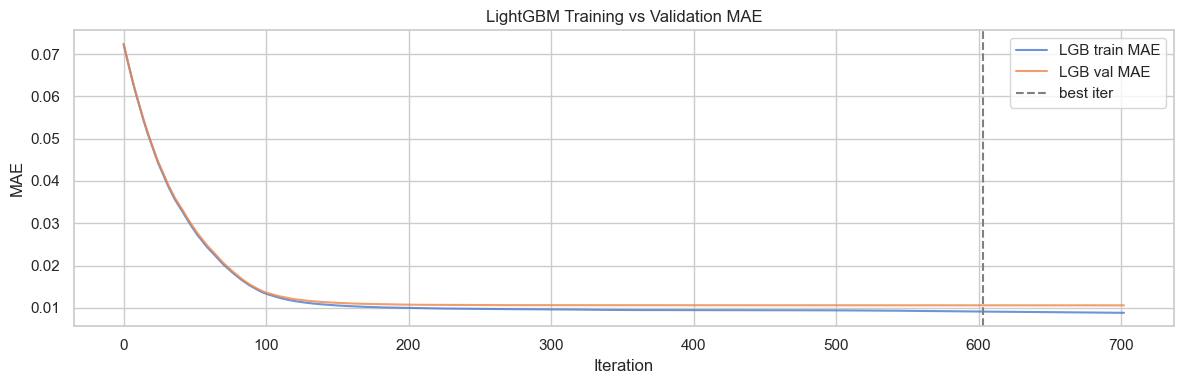

In [23]:
# ── 8.2  Loss curves ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lgb_evals['training']['l1'],  label='LGB train MAE', alpha=0.8)
ax.plot(lgb_evals['valid_1']['l1'],   label='LGB val MAE',   alpha=0.8)
ax.axvline(lgb_model.best_iteration_, color='gray', linestyle='--', label='best iter')
ax.set_xlabel('Iteration'); ax.set_ylabel('MAE')
ax.set_title('LightGBM Training vs Validation MAE')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()


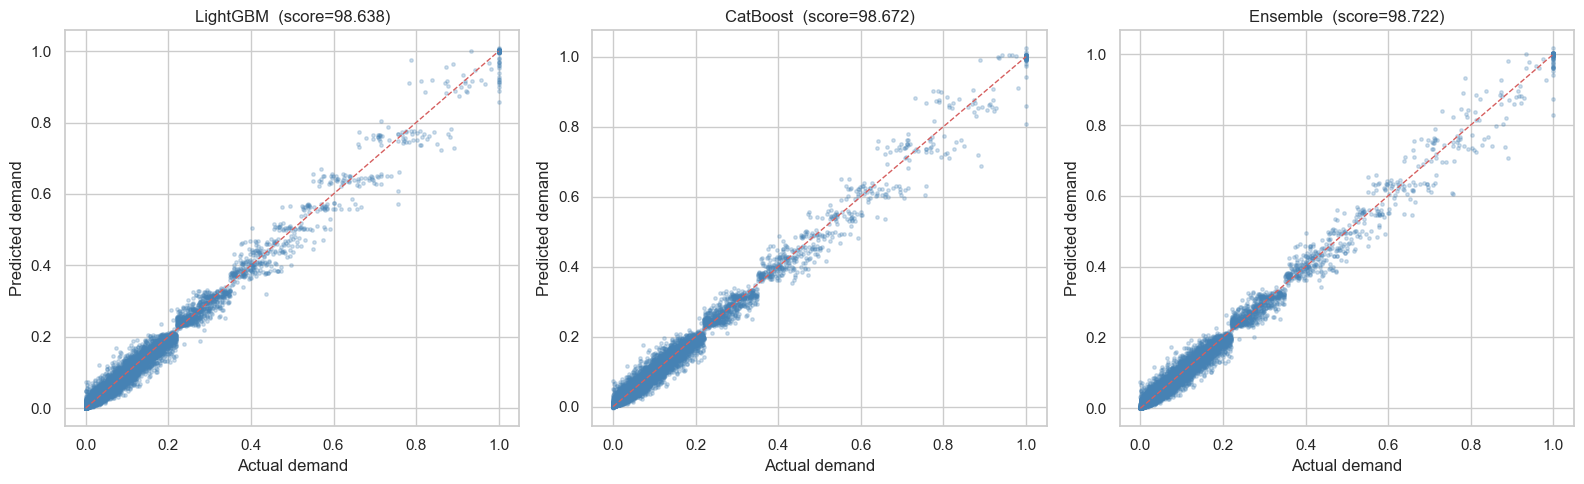

In [24]:
# ── 8.3  Predicted vs Actual ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, preds, title in zip(
    axes,
    [lgb_val_preds, cb_val_preds, ens_val_preds],
    ['LightGBM', 'CatBoost', 'Ensemble']
):
    ax.scatter(y_val, preds, alpha=0.25, s=6, color='steelblue')
    lo, hi = y_val.min(), y_val.max()
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'{title}  (score={score(y_val, preds):.3f})')
    ax.set_xlabel('Actual demand'); ax.set_ylabel('Predicted demand')
    ax.grid(True)

plt.tight_layout()
plt.show()


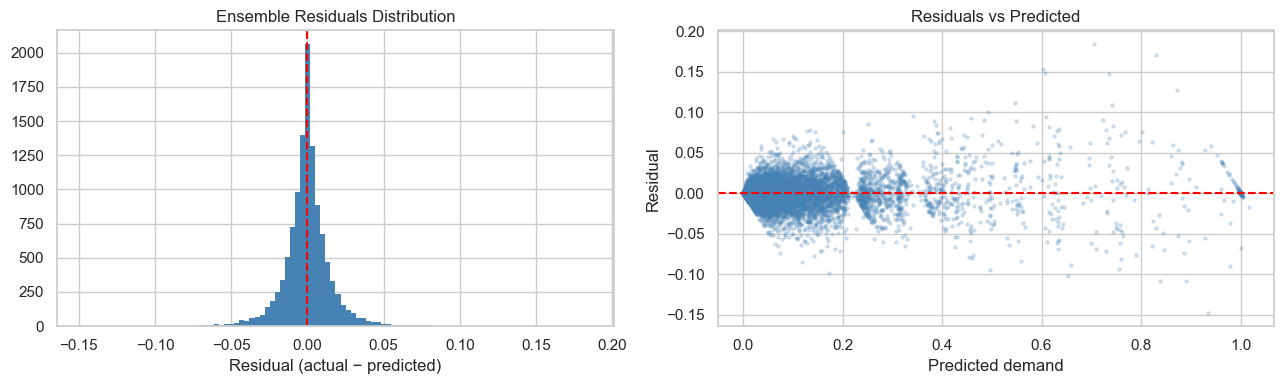

Residual mean  : 0.000057  (want ≈ 0)
Residual std   : 0.016085
|Residual| > 0.1: 0.11% of val rows


In [25]:
# ── 8.4  Residual distribution ───────────────────────────────────────────────
residuals = y_val.values - ens_val_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals, bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Ensemble Residuals Distribution')
axes[0].set_xlabel('Residual (actual − predicted)')

axes[1].scatter(ens_val_preds, residuals, alpha=0.2, s=5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted demand'); axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f'Residual mean  : {residuals.mean():.6f}  (want ≈ 0)')
print(f'Residual std   : {residuals.std():.6f}')
print(f'|Residual| > 0.1: {(np.abs(residuals) > 0.1).mean()*100:.2f}% of val rows')


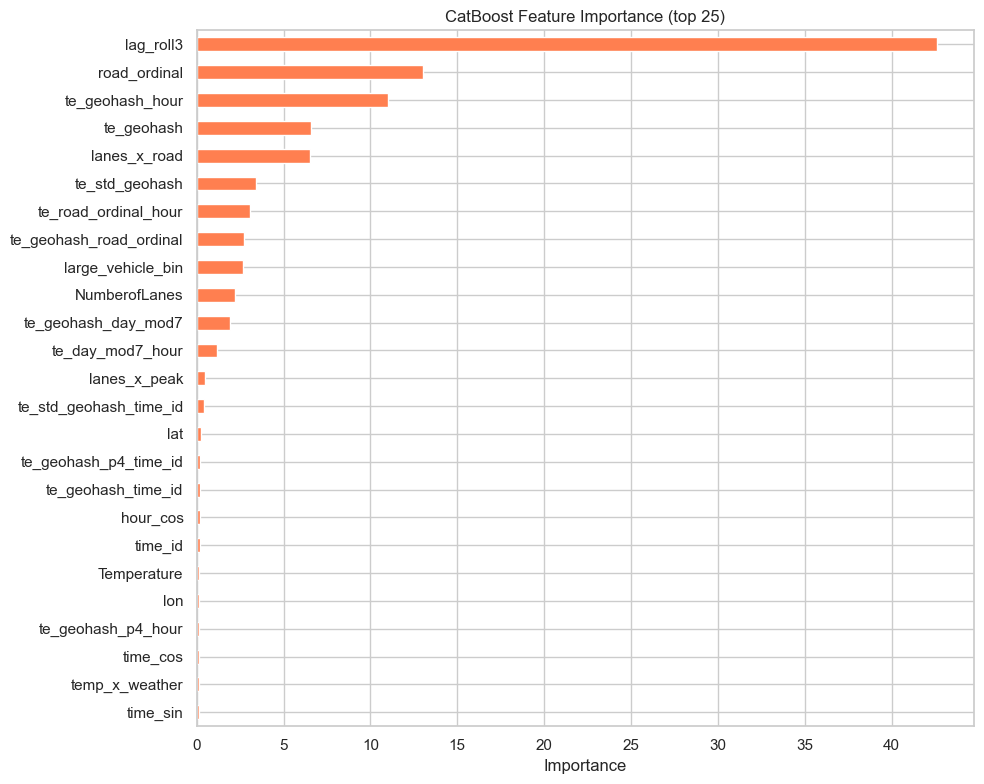

In [26]:
# ── 8.5  CatBoost feature importance ─────────────────────────────────────────
cb_imp = pd.Series(
    cb_model.get_feature_importance(),
    index=FINAL_FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
cb_imp.head(25)[::-1].plot(kind='barh', color='coral')
plt.title('CatBoost Feature Importance (top 25)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 9. Predict on Test Set & Save Submission

In [28]:
TEST_PATH = r'C:\Users\ARUN\Desktop\flipkart_gridlock\e88186124ec611f1\dataset\test.csv'   # update path if needed

test_raw = pd.read_csv(TEST_PATH)
test_ids = test_raw['Index'].copy()

test_feat = engineer_features(test_raw, target_enc_maps=enc_maps, is_train=False)

# Align columns to training
X_test = test_feat[FINAL_FEATURES]

lgb_test  = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration_)
cb_test   = cb_model.predict(X_test)
ens_test  = best_w * lgb_test + (1 - best_w) * cb_test

submission = pd.DataFrame({'Index': test_ids, 'demand': ens_test})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
submission.head()


Saved submission.csv


,Index,demand
0,0,0.063669
1,1,0.022585
2,2,0.086938
3,3,0.088458
4,4,0.053116
